## Setup inicial

Importaciones, carga de variables de entorno e inicialización de LLM.

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langfuse.langchain import CallbackHandler
from utils import logger
from vectorstore import initialize_chroma, create_collection, genera_y_almacena_embeddings, listar_collections
from carga_de_datos import carga_base_de_conocimientos

load_dotenv()

llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

print("=" * 60)
print("SETUP COMPLETADO")
print("=" * 60)

SETUP COMPLETADO


## Para cada dominio cargamos la bases de conocimiento, generamos embeddings y almacenamos en vector stores, una collection por cada dominio

In [2]:
model_name="text-embedding-3-small"
client, embedding_function = initialize_chroma(model=model_name)

dominios = ["finanzas", "rrhh", "soporte_it", "legal"]
for dominio in dominios:
    # collection = initialize_chroma(dominio)
    collection = create_collection(client, embedding_function, dominio)
    chunks = carga_base_de_conocimientos(dominio)
    genera_y_almacena_embeddings(chunks, collection)
    logger.info(
        f"Cargado {len(chunks)} chunks para el dominio {dominio}"
    )
print("vector db cargada")

2026-03-16 12:56:53,700 - Proyecto_M3 - INFO - Cargado 58 chunks para el dominio finanzas
2026-03-16 12:56:55,438 - Proyecto_M3 - INFO - Cargado 59 chunks para el dominio rrhh
2026-03-16 12:56:56,098 - Proyecto_M3 - INFO - Cargado 59 chunks para el dominio soporte_it
2026-03-16 12:56:56,958 - Proyecto_M3 - INFO - Cargado 58 chunks para el dominio legal


vector db cargada


In [3]:
# Check collections
listar_collections()



[Collection(name=soporte_it),
 Collection(name=legal),
 Collection(name=finanzas),
 Collection(name=rrhh)]

  ## Construccion de agentes y nodos

Los agentes se invocan con callbacks para que cada paso quede registrado en Langfuse.

In [4]:
from agentes.router import route_question
from agentes.constructor_de_agente import build_domain_agent
from langgraph.graph import StateGraph, START, END

hr_agent = build_domain_agent("rrhh")
it_agent = build_domain_agent("soporte_it")
legal_agent = build_domain_agent("legal")
finance_agent = build_domain_agent("finanzas")

langfuse_handler = CallbackHandler()

def router_node(state):
    question = state["question"]
    route = route_question(question)
    return {"route": route}

def hr_node(state):
    answer = hr_agent.invoke({"input": state["question"]}, config={"callbacks": [langfuse_handler]})
    return {"answer": answer["answer"]}

def it_node(state):
    answer = it_agent.invoke({"input": state["question"]}, config={"callbacks": [langfuse_handler]})
    return {"answer": answer["answer"]}

def legal_node(state):
    answer = legal_agent.invoke({"input": state["question"]}, config={"callbacks": [langfuse_handler]})
    return {"answer": answer["answer"]}

def finance_node(state):
    answer = finance_agent.invoke({"input": state["question"]}, config={"callbacks": [langfuse_handler]})
    return {"answer": answer["answer"]}

def na_node(state):
    return {"answer": "Lo siento, no puedo responder a esa pregunta."}


## Armado del grafo con routing condicional:

In [5]:
from typing import TypedDict

class GraphState(TypedDict):
    question: str
    route: str
    answer: str

builder = StateGraph(GraphState)

builder.add_node("router", router_node)
builder.add_node("hr", hr_node)
builder.add_node("it", it_node)
builder.add_node("legal", legal_node)
builder.add_node("finance", finance_node)
builder.add_node("na", na_node)

builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router",
    lambda state: state["route"],
    {
        "HR": "hr",
        "IT": "it",
        "LEGAL": "legal",
        "FINANCE": "finance",
        "NA": "na",
    },
)

for node in ["hr", "it", "finance", "legal"]:
    builder.add_edge(node, END)

graph = builder.compile()


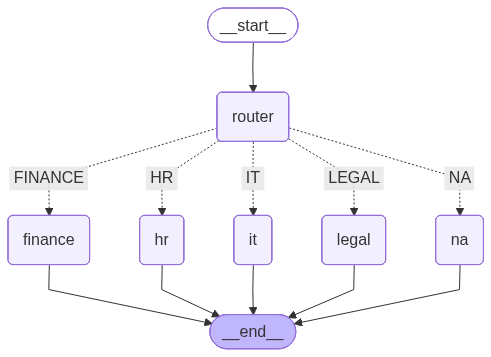

In [6]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## Prueba simple

In [7]:
query1 = "¿Puedo cambiar de plan durante el ciclo de facturación?"
query2 = "Cual es el actor principal de la pelicula back to the future?"
query3 = "¿Para qué se utilizan las cookies en IT?"
query4 = "¿La empresa puede eliminar contenido que viole las políticas?"
query5 = "¿En qué moneda se emiten las facturas del servicio?"

result = graph.invoke({"question": query5})
# print(result["answer"])
print(result)


{'question': '¿En qué moneda se emiten las facturas del servicio?', 'route': 'FINANCE', 'answer': 'Las facturas se emiten en diferentes monedas dependiendo de la región del cliente.'}


## Evaluación del grafo con dataset de preguntas y respuestas esperadas

In [20]:
import random
import copy
from carga_de_datos import cargar_dataset_evaluador
from consultas_border import consultas_adicionales_border


dataset_principal = cargar_dataset_evaluador()
random.shuffle(dataset_principal)  # Mezclamos el dataset para tener variedad en las preguntas de prueba
print(f"Total de consultas en el evaluador: {len(datasets)}")
# === Cantidad de consultas a realizar
consultas_a_realizar = 10
# ====================================
print(f"Consultas a realizar: {consultas_a_realizar}")
counter_consultas = 0
counter_correctas = 0
counter_incorrectas = 0
print("=" * 60)
datasets = list(dataset_principal)
border_added = False
for item in datasets:
    if counter_consultas > consultas_a_realizar and not border_added:
        datasets[counter_consultas+1:] = consultas_adicionales_border
        border_added = True
        consultas_a_realizar = 99
        print("\nConsultas border o que no estan en los datasets:\n")
        continue
    counter_consultas += 1
    result = graph.invoke({"question": item["pregunta"]})
    print(f"Consulta del usuario: {item["pregunta"]}")
    print(f"Consulta que uso el sistema: {result["question"]}")
    print(f"Ruta esperada: {item["dataset_correcto"]}")
    eval_ruta = "✅ Correcto !" if result["route"] == item["dataset_correcto"] else "❌ Incorrecto!"
    counter_correctas += 1 if result["route"] == item["dataset_correcto"] else 0
    counter_incorrectas += 1 if result["route"] != item["dataset_correcto"] else 0
    print(f"Ruta usada: {result["route"]} - {eval_ruta}")
    print(f"Respuesta: {result["answer"]}")
    print("=" * 60)


print("Estadistica")
print(f"Total de consultas: {counter_consultas}")
print(f"Total de consultas correctas: {counter_correctas}")
print(f"Total de consultas incorrectas: {counter_incorrectas}")
print(f"Porcentaje de aciertos: {(counter_correctas / counter_consultas) * 100:.2f}%")
print("=" * 60)





Total de consultas en el evaluador: 9
Consultas a realizar: 10
Consulta del usuario: ¿Cuántos intentos de cobro hace el sistema?
Consulta que uso el sistema: ¿Cuántos intentos de cobro hace el sistema?
Ruta esperada: FINANCE
Ruta usada: FINANCE - ✅ Correcto !
Respuesta: El contexto no especifica el número exacto de intentos de cobro que hace el sistema. Solo menciona que realiza varios intentos durante los días siguientes.
Consulta del usuario: ¿Quién es dueño de los datos que subo?
Consulta que uso el sistema: ¿Quién es dueño de los datos que subo?
Ruta esperada: LEGAL
Ruta usada: LEGAL - ✅ Correcto !
Respuesta: Los clientes conservan la propiedad completa de los datos que almacenan en la plataforma.
Consulta del usuario: ¿Qué pasa si mi pago falla?
Consulta que uso el sistema: ¿Qué pasa si mi pago falla?
Ruta esperada: FINANCE
Ruta usada: FINANCE - ✅ Correcto !
Respuesta: Si tu pago falla, el sistema iniciará automáticamente un proceso de reintento, realizando varios intentos durante